# 4. Mô hình học máy truyền thống (scikit-learn)

**Input:** `exps/feature0/`  
**Output:** log thực nghiệm, `exps/feature0/preds/*.npy`, file nộp `submission_*.csv`

BEGIN

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [3]:
MEMBER   = "TV2"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "traditional model2"
FEATURE_SET = "feature5"
SELECTION   = None   # None = tất cả cột; hoặc "lasso", "gbr_top50"...
seed_everything()

## VIỆC CỦA TV2 — làm trên `feature0` ngay từ đầu, khi có feature mới chỉ cần đổi `FEATURE_SET`
1. Thêm mô hình: ElasticNet, SVR, KNN, XGBoost/LightGBM (tùy chọn). Chép `get_traditional_models()` vào notebook rồi sửa.
2. Tinh chỉnh tham số bằng `GridSearchCV(make_pipeline(model), grid, cv=get_kfold(), scoring='neg_root_mean_squared_error')` — tên tham số có tiền tố `model__`.
3. Lập bảng: mô hình × feature set (feature0 → feature1/4 → feature5) cho báo cáo Chương 4, 6.
4. Lưu dự đoán bằng `save_preds()` để 5.improve dùng blend.

In [4]:
from models import get_traditional_models
x_train, y_train, x_test, test_id = load_feature_set(FEATURE_SET, SELECTION)

[load] feature5: x_train (1456, 262), x_test (1459, 262)


In [5]:
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = get_traditional_models()          # LR, Ridge, Lasso, RF, GBR (baseline)
models.update({
    'ENet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=50000),
    'SVR':  SVR(C=20, epsilon=0.01, gamma=0.0003),
    'KNN':  KNeighborsRegressor(n_neighbors=10, weights='distance'),
})

## 4.1. Đánh giá 5-fold CV
Mọi mô hình đều đi qua `make_pipeline()` (median imputer + StandardScaler) và cùng `get_kfold()`.

In [6]:
results = {}
for name, model in models.items():
    scores, oof = evaluate(model, x_train, y_train)
    results[name] = scores
    log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, name, scores, model.get_params(), SELECTION)
    save_preds(FEATURE_SET, f'{MEMBER}_{name}', oof, fit_predict(model, x_train, y_train, x_test))

[log] LR           | feature5/all | CV RMSE = 0.12543 ± 0.00564
[log] Ridge        | feature5/all | CV RMSE = 0.12201 ± 0.00612
[log] Lasso        | feature5/all | CV RMSE = 0.11732 ± 0.00589
[log] RF           | feature5/all | CV RMSE = 0.13501 ± 0.01072
[log] GBR          | feature5/all | CV RMSE = 0.11963 ± 0.00811
[log] ENet         | feature5/all | CV RMSE = 0.11729 ± 0.00591
[log] SVR          | feature5/all | CV RMSE = 0.11593 ± 0.00828
[log] KNN          | feature5/all | CV RMSE = 0.18666 ± 0.01735


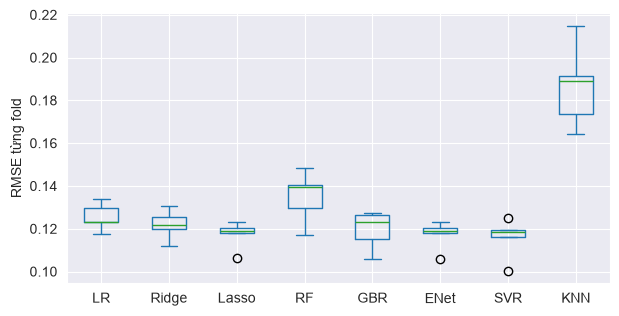

,mean,std
SVR,0.115929,0.009260
ENet,0.117288,0.006606
Lasso,0.117321,0.006582
GBR,0.119627,0.009064
Ridge,0.122015,0.006846
LR,0.125427,0.006304
RF,0.135012,0.011987
KNN,0.186664,0.019395


In [7]:
pd.DataFrame(results).plot.box(figsize=(7, 3.5), ylabel='RMSE từng fold'); plt.show()
pd.DataFrame(results).agg(['mean', 'std']).T.sort_values('mean')

## 4.2. Tạo file nộp cho mô hình tốt nhất

In [8]:
best = min(results, key=lambda k: results[k].mean())
pred = np.load(f'{feature_dir(FEATURE_SET)}/preds/{MEMBER}_{best}_test.npy')
save_submission(FEATURE_SET, f'{MEMBER}_{best}', test_id, pred)

[submit] d:/HocSau/House_Prices/house_prices_project/exps/feature5\submission_TV2_SVR.csv


'd:/HocSau/House_Prices/house_prices_project/exps/feature5\\submission_TV2_SVR.csv'

In [9]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor

GRIDS = {
    'Ridge': (Ridge(), {'model__alpha': [1, 3, 10, 30, 100, 200, 300, 500, 1000]}),       
    'Lasso': (Lasso(max_iter=50000), {'model__alpha': [1e-4, 3e-4, 1e-3, 3e-3, 5e-3, 1e-2]}),  
    'ENet':  (ElasticNet(max_iter=50000), {'model__alpha': [3e-4, 5e-4, 1e-3],
                                           'model__l1_ratio': [0.3, 0.5, 0.7]}),
    'GBR':   (GradientBoostingRegressor(n_estimators=1000, learning_rate=0.03, subsample=0.8, random_state=SEED),
              {'model__max_depth': [2, 3], 'model__max_features': ['sqrt', None]}),
}

tuned = {}
for name, (model, grid) in GRIDS.items():
    gs = GridSearchCV(make_pipeline(model), grid, cv=get_kfold(),
                      scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(x_train, y_train)
    best = gs.best_estimator_.named_steps['model']
    scores, oof = evaluate(best, x_train, y_train)
    log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, f'{name}_tuned', scores, gs.best_params_, SELECTION)
    save_preds(FEATURE_SET, f'{MEMBER}_{name}_tuned', oof, fit_predict(best, x_train, y_train, x_test))
    tuned[name] = {'best_params': gs.best_params_, 'cv_rmse': round(scores.mean(), 5)}

pd.DataFrame(tuned).T

[log] Ridge_tuned  | feature5/all | CV RMSE = 0.11491 ± 0.00729
[log] Lasso_tuned  | feature5/all | CV RMSE = 0.11179 ± 0.00676
[log] ENet_tuned   | feature5/all | CV RMSE = 0.11616 ± 0.00568
[log] GBR_tuned    | feature5/all | CV RMSE = 0.11210 ± 0.00652


,best_params,cv_rmse
Ridge,{'model__alpha': 300},0.11491
Lasso,{'model__alpha': 0.003},0.11179
ENet,"{'model__alpha': 0.001, 'model__l1_ratio': 0.7}",0.11616
GBR,"{'model__max_depth': 2, 'model__max_features':...",0.1121


In [10]:
log = pd.read_csv(f'{logs_dir}/experiments_{MEMBER}.csv')
log.pivot_table(index='model', columns='feature_set', values='cv_rmse', aggfunc='last').round(4)

feature_set,feature0,feature5
model,,
ENet,0.1443,0.1173
ENet_tuned,0.1436,0.1162
GBR,0.1302,0.1196
GBR_tuned,0.1234,0.1121
KNN,0.2039,0.1867
LR,0.1488,0.1254
Lasso,0.1443,0.1173
Lasso_tuned,0.1410,0.1118
RF,0.1446,0.1350


### Kết luận
- Trên feature5, Lasso_tuned (0.1118) và GBR_tuned (0.1121) tốt nhất; KNN kém nhất do dữ liệu nhiều chiều. Từ feature0 sang feature5 mọi mô hình cải thiện 0.01–0.03; tham số regularization tối ưu thay đổi khi đã loại ngoại lai.